<a href="https://colab.research.google.com/github/EML-Labs/Feature_Analysis/blob/main/Feature_Extractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
# import wfdb
from pathlib import Path
from typing import List, Tuple, Optional, Dict
from scipy.spatial.distance import pdist, squareform
from collections import Counter
from scipy import stats
from collections import deque



In [3]:
class SegmentExtractor:
    """Helper functions to extract pre-AF and AF data from extracted segments"""

    def __init__(self, extracted_segments_dir: str, extraction_report_path: str):

        self.segments_dir = Path(extracted_segments_dir)
        self.report_df = pd.read_csv(extraction_report_path)

    def get_segment_info(self, segment_name: str) -> Optional[Dict]:

        row = self.report_df[self.report_df['Segment_Name'] == segment_name]
        if row.empty:
            print(f"Segment {segment_name} not found in extraction report")
            return None
        return row.iloc[0].to_dict()

    def extract_data(self, segment_name: str, extract_type: str) -> Tuple[Optional[np.ndarray], Optional[Dict]]:
        # Get segment info from report
        info = self.get_segment_info(segment_name)
        if info is None:
            return None, None
        try:
            # Load the full record
            record_path = self.segments_dir / segment_name
            record = wfdb.rdrecord(str(record_path))
            annotation = wfdb.rdann(str(record_path), 'atr')

            fs = int(record.fs)
            pre_af_minutes = info['Pre_AF_Minutes_Extracted']
            af_duration_minutes = info['AF_Duration_Minutes']

            # Calculate pre-AF samples (pre-AF is at the beginning of the segment)
            pre_af_samples = int(pre_af_minutes * 60 * fs)
            af_samples = int(af_duration_minutes * 60 * fs)

            af_start = pre_af_samples
            af_end = pre_af_samples + af_samples

            if extract_type == 'preaf':
                extracted_data = record.p_signal[:pre_af_samples, :]
                minutes_extracted = pre_af_minutes
                samples_extracted = pre_af_samples
            else:
                extracted_data = record.p_signal[af_start:af_end, :]
                minutes_extracted = af_duration_minutes
                samples_extracted = af_samples

            # Load QRS annotations
            try:
                qrs_ann = wfdb.rdann(str(record_path), 'qrs')
                if extract_type == 'preaf':
                    qrs_mask = qrs_ann.sample < pre_af_samples
                    qrs_samples = qrs_ann.sample[qrs_mask]
                else:
                    qrs_mask = (qrs_ann.sample >= af_start) & (qrs_ann.sample < af_end)
                    qrs_samples = qrs_ann.sample[qrs_mask] - af_start
                qrs_symbols = [qrs_ann.symbol[i] for i in range(len(qrs_ann.symbol))
                                  if qrs_mask[i]]
            except:
                qrs_samples = np.array([])
                qrs_symbols = []

            metadata = {
                'segment_name': segment_name,
                'record_id': info['Record_ID'],
                'episode_number': info['Episode_Number'],
                'duration_minutes': minutes_extracted,
                'duration_seconds': minutes_extracted * 60,
                'n_samples': samples_extracted,
                'sampling_frequency': fs,
                'n_channels': extracted_data.shape[1],
                'signal_names': record.sig_name[:extracted_data.shape[1]],
                'units': record.units[:extracted_data.shape[1]],
                'qrs_samples': qrs_samples,
                'qrs_symbols': qrs_symbols,
                'n_beats': len(qrs_samples)
            }

            if(extract_type == 'preaf'):
                print(f"✓ Extracted pre-AF data for {segment_name}: "
                  f"{minutes_extracted:.1f} min, {len(qrs_samples)} beats")
            else:
                print(f"✓ Extracted AF data for {segment_name}: "
                  f"{minutes_extracted:.1f} min, {len(qrs_samples)} beats")

            return extracted_data, metadata

        except Exception as e:
            print(f"Failed to extract data for {segment_name}: {e}")
            return None, None

    def extract_preaf_data(self, segment_name: str) -> Tuple[Optional[np.ndarray], Optional[Dict]]:
        return self.extract_data(segment_name, 'preaf')

    def extract_af_data(self, segment_name: str) -> Tuple[Optional[np.ndarray], Optional[Dict]]:
        return self.extract_data(segment_name, 'af')


    def extract_both(self, segment_name: str) -> Dict:
        preaf_ecg, preaf_meta = self.extract_preaf_data(segment_name)
        af_ecg, af_meta = self.extract_af_data(segment_name)

        return {
            'preaf': (preaf_ecg, preaf_meta),
            'af': (af_ecg, af_meta)
        }

    def get_rr_intervals(self, qrs_samples: np.ndarray, fs: int) -> Tuple[np.ndarray, np.ndarray]:
        if len(qrs_samples) < 2:
            return np.array([]), np.array([])

        beat_times = qrs_samples / fs
        rr_intervals = np.diff(beat_times)

        return rr_intervals, beat_times[1:]

In [4]:
class Feature_Extractor:
  # To get recurrence matrix with embedding

  # max items is the amount of times to consider to get temporal featues
  def __init__(self, max_items):
    self.feature_queues = {
      'SDNN': deque(maxlen=max_items),
      'RMSSD': deque(maxlen=max_items),
      'mean_hr': deque(maxlen=max_items),
      'pnn50': deque(maxlen=max_items),
      'det': deque(maxlen=max_items),
      'trapping_time': deque(maxlen=max_items),
      'lmax': deque(maxlen=max_items),
    }

    self.time_points = deque(maxlen=max_items)

  @staticmethod
  def RQA(rr_intervals:np.ndarray, m , tau, rr_percent, l_min, v_min, l_max, exclude_loi=True)-> Dict[str, float]:
    rr_intervals = np.asarray(rr_intervals)
    N = len(rr_intervals)
    M = N - (m - 1)*tau
    if N <= 0:
      raise ValueError("Time series too short for given m and tau")
    state_space =  np.zeros((M, m))

    for i in range(M):
      state_space[i] = rr_intervals[i: i + m * tau : tau]

    D = np.max(np.abs(state_space[:, None, :] - state_space[None, :, :]), axis=2)
    len_D = D.shape[0]
    upper_triangle = D[np.triu_indices(len_D, k=1)]
    eps = np.percentile(upper_triangle, rr_percent * 100)

    R = (D <= eps).astype(int)
    len_R = R.shape[0]
    Rb = (np.asarray(R) != 0).astype(np.uint8)

    if exclude_loi:
        np.fill_diagonal(Rb, 0)

    # Recurrence Rate
    recurrence_rate = np.sum(Rb) / (len_R ** 2) if len_R > 0 else 0.0

    counts = Feature_Extractor._p_of_l(Rb, len_R)
    counts_lmin = {l: c for l, c in counts.items() if l >= l_min}

    counts_vertical = Feature_Extractor._p_of_v(Rb, M)
    counts_vertical_lmin = {v: c for v, c in counts_vertical.items() if v >= v_min}

    total_counts = sum(counts_lmin.values())
    sum_l_pl = sum(L * c for L, c in counts_lmin.items())
    sum_l_pl_all = sum(L * c for L, c in counts.items())

    # Determinism
    determinism = sum_l_pl / sum_l_pl_all if sum_l_pl_all > 0 else 0.0

    # L mean
    L_mean = sum_l_pl / total_counts if total_counts > 0 else 0.0

    # L max
    L_max = max(counts_lmin.keys()) if counts_lmin else 0.0

    # Median diagonal line length
    if counts_lmin:
        lengths_expanded = []
        for L, c in counts_lmin.items():
            lengths_expanded.extend([L] * c)
        L_median = np.median(lengths_expanded)
    else:
        L_median = np.nan

    # Entropy
    probs = {L: c / total_counts for L, c in counts_lmin.items()} if total_counts > 0 else {}
    entropy = float(-sum(p * np.log(p) for p in probs.values()) if probs else 0.0)

    # Divergence - Can use as Lyapunov exponent
    divergence = 1.0 / L_max if L_max > 0 else 0.0

    ratio = determinism / recurrence_rate if recurrence_rate > 0 else 0.0

    counts_vertical_sum = sum(counts_vertical_lmin.values())
    sum_v_pl = sum(v * c for v, c in counts_vertical_lmin.items())
    sum_v_pl_all = sum(v * c for v, c in counts_vertical.items())

    # Laminarity (LAM)
    laminarity = sum_v_pl / sum_v_pl_all if sum_v_pl_all > 0 else 0.0

    # Trapping time (TT)
    trapping_time = sum_v_pl / counts_vertical_sum if counts_vertical_sum > 0 else 0.0

    # Maximum vertical line length (V_max)
    V_max = max(counts_vertical_lmin.keys()) if counts_vertical_lmin else 0.0

    # Vertical line entropy (V_entr)
    probs_v = {v: c / counts_vertical_sum for v, c in counts_vertical_lmin.items()} if counts_vertical_sum > 0 else {}
    V_entr = float(-sum(p * np.log(p) for p in probs_v.values()) if probs_v else 0.0)

    # 9. White vertical lines (time between recurrences)
    white_vertical_lengths = []
    for j in range(M):
        col = Rb[:, j]
        # Find runs of zeros (non-recurrent points)
        zero_runs = _lengths_of_consecutive_ones(1 - col)  # Invert: 0->1, 1->0
        white_vertical_lengths.extend(zero_runs)

    W_mean = np.mean(white_vertical_lengths) if white_vertical_lengths else np.nan
    W_max = np.max(white_vertical_lengths) if white_vertical_lengths else np.nan

    pc = Feature_Extractor._compute_pc_l(Rb, l_max)
    lg_pc = Feature_Extractor._log_pc(pc)
    l_vals = np.arange(1, l_max + 1)
    K2 = Feature_Extractor._detect_scaling_region_and_estimate_K2(l_vals, log_pc)

    features = {
        # Diagonal Features
        'recurrence_rate' : recurrence_rate,
        'determinism' : determinism,
        'l_mean' : L_mean,
        'l_max' : L_max,
        'l_median' : L_median,
        'l_entropy' : entropy,
        'divergence' : divergence,
        'ratio' : ratio,
        'lmin_count' : total_counts,

        # Vertical Features
        'laminarity' : laminarity,
        'trapping_time' : trapping_time,
        'v_max' : V_max,
        'v_entropy' : V_entr,

        # White Vertical Features
        'w_mean' : W_mean,
        'w_max' : W_max,

        # Advanved features
        'K2' : K2
    }

    return features

  @staticmethod
  def _lengths_of_consecutive_ones(arr):
    array = np.asarray(arr, dtype=np.int8)
    if array.size == 0:
        return np.array([], dtype=int)
    edges = np.diff(np.r_[0, array, 0])
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    return (ends - starts).tolist()

  @staticmethod
  def _p_of_l(Rb: np.ndarray, M: int) -> Dict[int, int]:
    counts = Counter()
    for k in range(-(M - 1), M):
        diag = np.diagonal(Rb, offset=k)
        for L in Feature_Extractor._lengths_of_consecutive_ones(diag):
            counts[L] += 1
    return dict(counts)

  @staticmethod
  def _p_of_v(Rb: np.ndarray, M: int) -> Dict[int, int]:
      counts = {}
      for j in range(M):
          col = Rb[:, j]
          runs = Feature_Extractor._lengths_of_consecutive_ones(col)
          for v in runs:
              counts[v] = counts.get(v, 0) + 1
      return counts

  @staticmethod
  def _compute_pc_l(Rb: np.ndarray, l_max: int) -> np.ndarray:
    N = Rb.shape[0]
    diag_lengths = []

    for k in range(-N + 1, N):
        diag = np.diagonal(Rb, offset=k)
        # print("Diagonal now:", diag)
        count = 0
        for val in diag:
            if val == 1:
                count += 1
            else:
                if count > 0:
                    diag_lengths.append(count)
                count = 0
        if count > 0:
            diag_lengths.append(count)

    diag_lengths = np.array(diag_lengths)
    # print("Diagonal Lengths:", diag_lengths)
    pc = []
    for l in range(1, l_max + 1):
        pc.append(np.sum(diag_lengths >= l))
    pc = np.array(pc, dtype=float)
    pc /= pc[0]  # normalize by the diagonal
    return pc

  @staticmethod
  def _log_pc(pc: np.ndarray) -> np.ndarray:
    pc = np.clip(pc, 1e-12, None)
    return np.log(pc)


  @staticmethod
  def _detect_scaling_region_and_estimate_K2(
      l_vals: np.ndarray ,
      log_pc_vals: np.ndarray,
      min_len=3,
      r2_threshold=0.95,
      min_slope = -0.001) -> float:
    best_score = -np.inf
    best_region = None
    K2 = None

    for i in range(len(l_vals)):
        if l_vals[i] < 3:
            continue
        for j in range(i + min_len, len(l_vals) + 1):
            x = l_vals[i:j].reshape(-1, 1)
            y = log_pc_vals[i:j]
            model = LinearRegression().fit(x, y)
            r2 = model.score(x, y)
            slope = model.coef_[0]
            if r2 >= r2_threshold and slope <= min_slope:
                length = j - i
                mean_l = np.mean(l_vals[i:j])
                score = length * np.log(mean_l + 1)

                if score > best_score:
                    best_score = score
                    best_region = (i, j)
                    K2 = -slope

    return K2

  @staticmethod
  def HRV(rr_intervals:np.ndarray)-> Dict[str, float]:
    # Nedd to RR intervals in ms rather than s
    # HRV done in ms
    rr_intervals = rr_intervals * 1000
    diff_rr = np.diff(rr_intervals)
    rr1 = rr_intervals[:-1]
    rr2 = rr_intervals[1:]
    sd1 = np.sqrt(0.5*np.var(rr1 - rr2, ddof=1))
    sd2 = np.sqrt(0.5*np.var(rr1 + rr2, ddof=1))
    # 128Hz bin width
    histogram, _ = np.histogram(rr_intervals, bins=int((np.max(rr_intervals) - np.min(rr_intervals))/ 7.1825))
    features = {
        'mean_rr': np.mean(rr_intervals),
        'median_rr': np.median(rr_intervals),
        'max_rr': np.max(rr_intervals),
        'min_rr': np.min(rr_intervals),
        'rr_range': np.max(rr_intervals) - np.min(rr_intervals),

        'sdnn': np.std(rr_intervals, ddof=1),
        'rmssd': np.sqrt(np.mean(diff_rr**2)),
        'sdsd': np.std(diff_rr, ddof=1),

        'pnn50': 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr) if len(diff_rr) > 0 else 0,
        'pnn20': 100 * np.sum(np.abs(diff_rr) > 20) / len(diff_rr) if len(diff_rr) > 0 else 0,

        'mean_hr': 60000 / np.mean(rr_intervals) if np.mean(rr_intervals) > 0 else 0,
        'cov_rr': np.std(rr_intervals, ddof=1)/ np.mean(rr_intervals) if np.mean(rr_intervals) > 0 else 0,

        # Geometric features
        'sd1' : sd1,
        'sd2' : sd2,
        'sdratio' : sd1 / sd2 if sd2 > 0 else 0,

        'triangular_index' : len(rr_intervals) / np.max(histogram) if np.max(histogram) > 0 else 0

    }

    return features

  @staticmethod
  def nonlinear_features(rr_intervals: np.ndarray) -> Dict[str, float]:
      rr_ms = rr_intervals * 1000

      features = {}

      # Sample Entropy - Quantify the complexity, irregularity, or unpredictability of time-series data
      try:
          features['sampen'] = Feature_Extractor._sample_entropy(rr_ms, m=2, r=0.2*np.std(rr_ms))
      except:
          features['sampen'] = 0.0

      # Approximate Entropy
      try:
          features['apen'] = Feature_Extractor._approximate_entropy(rr_ms, m=2, r=0.2*np.std(rr_ms))
      except:
          features['apen'] = 0.0

      # DFA
      try:
          alpha1, alpha2 = Feature_Extractor._dfa(rr_ms)
          features['dfa_alpha1'] = alpha1
          # features['dfa_alpha2'] = alpha2
      except:
          features['dfa_alpha1'] = 0.0
          # features['dfa_alpha2'] = 0.0

      # Multiscale entropy (simplified)
      try:
          features['multiscale_entropy'] = Feature_Extractor._multiscale_entropy(rr_ms)
      except:
          features['multiscale_entropy'] = 0.0

      return features

  @staticmethod
  def _sample_entropy(data, m=2, r=None):
      """Calculate Sample Entropy"""
      if r is None:
          r = 0.2 * np.std(data)

      N = len(data)

      def _phi(m):
          patterns = np.array([data[i:i+m] for i in range(N-m)])
          count = 0
          for i in range(len(patterns)):
              distances = np.max(np.abs(patterns - patterns[i]), axis=1)
              count += np.sum(distances <= r) - 1  # Exclude self-match
          return count

      phi_m = _phi(m)
      phi_m1 = _phi(m+1)

      if phi_m == 0 or phi_m1 == 0:
          return 0.0

      return -np.log(phi_m1 / phi_m)

  @staticmethod
  def _approximate_entropy(data, m=2, r=None):
      """Calculate Approximate Entropy"""
      if r is None:
          r = 0.2 * np.std(data)

      N = len(data)

      def _phi(m):
          patterns = np.array([data[i:i+m] for i in range(N-m+1)])
          C = np.zeros(N-m+1)
          for i in range(N-m+1):
              distances = np.max(np.abs(patterns - patterns[i]), axis=1)
              C[i] = np.sum(distances <= r) / (N-m+1)
          return np.sum(np.log(C)) / (N-m+1)

      return _phi(m) - _phi(m+1)

  @staticmethod
  def _dfa(data):
      """Detrended Fluctuation Analysis"""
      N = len(data)
      data = data - np.mean(data)
      y = np.cumsum(data)

      scales = np.unique(np.logspace(0.5, np.log10(N//4), 20).astype(int))
      F = []

      for scale in scales:
          segments = N // scale
          F_n = []
          for v in range(segments):
              segment = y[v*scale:(v+1)*scale]
              x = np.arange(len(segment))
              coeff = np.polyfit(x, segment, 1)
              fit = np.polyval(coeff, x)
              F_n.append(np.sqrt(np.mean((segment - fit)**2)))
          F.append(np.mean(F_n))

      F = np.array(F)
      scales = scales[:len(F)]

      # Fit short and long term
      log_scales = np.log(scales)
      log_F = np.log(F)

      mid = len(scales) // 2
      alpha1 = np.polyfit(log_scales[:mid], log_F[:mid], 1)[0]
      # alpha2 = np.polyfit(log_scales[mid:], log_F[mid:], 1)[0]

      return alpha1

  @staticmethod
  def _multiscale_entropy(data, scales=range(1, 6)):
      """Multiscale entropy"""
      entropies = []
      for scale in scales:
          if scale == 1:
              coarse = data
          else:
              n = len(data) // scale
              coarse = np.mean(data[:n*scale].reshape(n, scale), axis=1)

          if len(coarse) > 10:
              try:
                  ent = Feature_Extractor._sample_entropy(coarse)
                  entropies.append(ent)
              except:
                  pass

      return np.mean(entropies) if entropies else 0.0

  @staticmethod
  def temporal_features(features_history: Dict[str, List[float]],
                        temporal_feature_set: Dict[str, List[str]],
                        time_points: List[int],
                        time_start: int,
                        time_end: int,
                        durantion: int) -> Dict[str, float] :

    features:Dict[str, float] = {}

    features['time_from_start'] = -time_start
    features['time_to_end'] = -time_end


    for feature_name, feature_values in features_history.items():
      if feature_name not in temporal_feature_set:
        continue

      temporal_ops = temporal_feature_set[feature_name]
      if len(feature_values) < 2:
        continue
      if "slope" in temporal_ops:
        features[f'{feature_name}_slope'] = Feature_Extractor._compute_slope(feature_values, time_points)
      if "acceleration" in temporal_ops:
        features[f'{feature_name}_acceleration'] = Feature_Extractor._compute_acceleration(feature_values, time_points)
      if "volatility" in temporal_ops:
        features[f'{feature_name}_volatility'] = Feature_Extractor._compute_volatility(feature_values)
      if "zscore" in temporal_ops:
        features[f'{feature_name}_zscore'] = Feature_Extractor._compute_zscore(feature_values)
    return features



  @staticmethod
  def _compute_slope(feature_values: List[float], time_points: List[float]) -> float:
    if len(feature_values) < 2:
        return 0.0

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        time_points, feature_values
    )
    return slope

  @staticmethod
  def _compute_acceleration(feature_values: List[float], time_points: List[float]) -> float:
    if len(feature_values) < 2:
        return 0.0

    velocities = np.diff(feature_values) / np.diff(time_points)
    if len(velocities) > 1:
        time_diff_velocity = (time_points[2:] - time_points[:-2]) / 2
        accelerations = np.diff(velocities) / time_diff_velocity
        mean_acceleration = np.mean(accelerations)
    else:
        mean_acceleration = 0.0

    return mean_acceleration

  @staticmethod
  def _compute_volatility(feature_values: List[float]) -> float:
    if len(feature_values) < 2:
        return 0.0
    volatility = np.std(feature_values)

    return volatility

  @staticmethod
  def _compute_zscore(feature_values: List[float]) -> float:
    if len(feature_values) < 2:
        return 0.0
    mean_value = np.mean(feature_values)
    std_value = np.std(feature_values)
    if std_value != 0:
        zscore = (feature_values[-1] - mean_value) / std_value

    return zscore

  def extract_features(self, rr_intervals:np.ndarray,
                       m:int ,
                       tau:int,
                       rr_percent:float,
                       l_min:int,
                       v_min:int,
                       l_max:int,
                       start_time:int,
                       end_time:int,
                       extract_temporat_features= True) -> Dict[str, float]:

    features:Dict[str, float] = {}

    temporal_features_set = {
      'SDNN': ['slope', 'acceleration', 'volatility', 'zscore'],
      'RMSSD': ['slope', 'zscore'],
      'mean_hr': ['slope', 'zscore'],
      'pnn50': ['slope'],
      'det': ['slope'],
      'trapping_time': ['slope'],
      'lmax': ['slope'],
    }

    features.update(
        Feature_Extractor.HRV(rr_intervals)
    )

    features.update(
        Feature_Extractor.RQA(
            rr_intervals, m, tau, rr_percent, l_min, v_min, l_max
        )
    )

    features.update(
        Feature_Extractor.nonlinear_features(rr_intervals)
    )

    if not extract_temporal_features:
      return features

    # temporal_base_features = {
    #     k: features[k] for k in temporal_features_set.keys()
    #     if k in features
    # }

    self.time_points.append(start_time)

    # temporal values : A list containing values to calculate temporal features
    temporal_data: Dict[str, List[float]] = {}


    for feature_name, temporal_ops in temporal_features_set.items():
      if feature_name not in features:
        continue
      feature_value = features[feature_name]
      q = self.feature_queues[feature_name]

      q.append(feature_value)

      if len(q) > 0:
        temporal_data[feature_name] = list(q)
      else:
        temporal_data[feature_name] = []

      time_points = list(self.time_points)


    features.update(
        Feature_Extractor.temporal_features(
          temporal_data, temporal_features_set, time_points, start_time, end_time
        )
    )

    return features


# Unit Tests



HRV FEATURE EXTRACTION TEST SUITE
Testing 120-minute pre-AF data segmented into 10-minute windows

TEST 1: Single 10-minute segment HRV extraction

Generated 700 RR intervals for 10-minute segment
Mean RR: 859.84 ms
SDNN: 68.06 ms

--------------------------------------------------------------------------------
Extracted HRV Features:
--------------------------------------------------------------------------------
mean_rr             :   859.8375
median_rr           :   856.2080
max_rr              :  1125.8420
min_rr              :   684.0790
rr_range            :   441.7629
sdnn                :    68.0574
rmssd               :    94.4935
sdsd                :    94.5611
pnn50               :    58.7983
pnn20               :    80.9728
mean_hr             :    69.7806
cov_rr              :     0.0792
sd1                 :    66.8648
sd2                 :    69.2731
sdratio             :     0.9652
triangular_index    :    18.4211

----------------------------------------------------

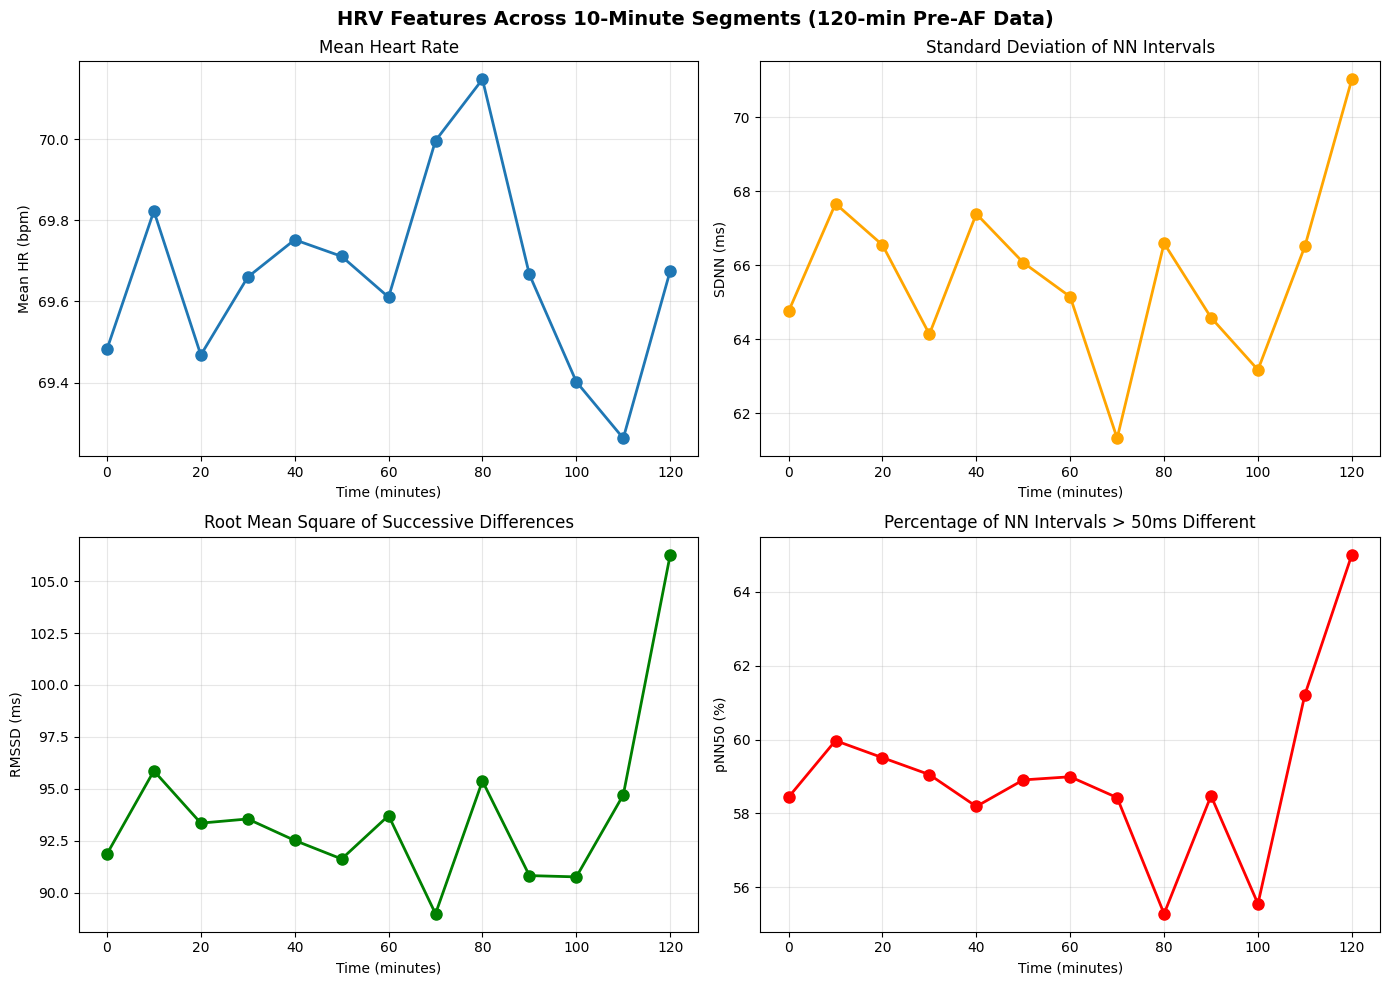

In [9]:
"""
Test case for HRV feature extraction from 120-minute pre-AF data
Segments: 12 segments of 10 minutes each for survival analysis
"""

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Dict, List
import sys

# Add your module path if needed
# sys.path.append('/path/to/your/modules')

# Import your classes (adjust the import based on your actual module structure)
# from your_module import SegmentExtractor, Feature_Extractor


def generate_synthetic_rr_intervals(duration_minutes: int, fs: int = 360,
                                    mean_hr: float = 70, hr_variability: float = 5) -> np.ndarray:
    """
    Generate synthetic RR intervals for testing

    Args:
        duration_minutes: Duration in minutes
        fs: Sampling frequency (Hz)
        mean_hr: Mean heart rate (bpm)
        hr_variability: Standard deviation of HR (bpm)

    Returns:
        RR intervals in milliseconds
    """
    total_seconds = duration_minutes * 60
    mean_rr_ms = 60000 / mean_hr  # Mean RR interval in ms

    # Generate heart rate variations
    num_beats = int(total_seconds * (mean_hr / 60))
    hr_variations = np.random.normal(mean_hr, hr_variability, num_beats)

    # Convert to RR intervals (in ms)
    rr_intervals = 60000 / hr_variations

    # Add some realistic variability
    rr_intervals += np.random.normal(0, 20, num_beats)  # Add ~20ms noise

    # Ensure no negative or extremely short intervals
    rr_intervals = np.clip(rr_intervals, 300, 2000)

    return rr_intervals


def validate_hrv_features(features: Dict[str, float], rr_intervals: np.ndarray) -> Dict[str, bool]:
    """
    Validate extracted HRV features against manual calculations

    Args:
        features: Extracted features dictionary
        rr_intervals: RR intervals in milliseconds

    Returns:
        Dictionary of validation results
    """
    validation = {}
    tolerance = 1e-6

    # Manual calculations
    diff_rr = np.diff(rr_intervals)

    # Basic statistics
    manual_mean_rr = np.mean(rr_intervals)
    manual_median_rr = np.median(rr_intervals)
    manual_sdnn = np.std(rr_intervals, ddof=1)
    manual_rmssd = np.sqrt(np.mean(diff_rr**2))

    # Check basic features
    validation['mean_rr'] = np.abs(features.get('mean_rr', 0) - manual_mean_rr) < tolerance
    validation['median_rr'] = np.abs(features.get('median_rr', 0) - manual_median_rr) < tolerance
    validation['sdnn'] = np.abs(features.get('sdnn', 0) - manual_sdnn) < tolerance
    validation['rmssd'] = np.abs(features.get('rmssd', 0) - manual_rmssd) < tolerance

    # Check pNN50
    manual_pnn50 = 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr) if len(diff_rr) > 0 else 0
    validation['pnn50'] = np.abs(features.get('pnn50', 0) - manual_pnn50) < tolerance

    # Check heart rate
    manual_hr = 60000 / manual_mean_rr if manual_mean_rr > 0 else 0
    validation['mean_hr'] = np.abs(features.get('mean_hr', 0) - manual_hr) < tolerance

    return validation


def segment_rr_intervals(rr_intervals: np.ndarray, segment_duration_sec: int = 600) -> List[np.ndarray]:
    """
    Segment RR intervals into fixed-duration segments

    Args:
        rr_intervals: RR intervals in milliseconds
        segment_duration_sec: Duration of each segment in seconds (default: 600s = 10 min)

    Returns:
        List of RR interval segments
    """
    segments = []
    cumulative_time = np.cumsum(rr_intervals) / 1000  # Convert to seconds

    current_start_idx = 0
    segment_end_time = segment_duration_sec

    for i, time in enumerate(cumulative_time):
        if time >= segment_end_time:
            segments.append(rr_intervals[current_start_idx:i])
            current_start_idx = i
            segment_end_time += segment_duration_sec

    # Add the last segment if there's remaining data
    if current_start_idx < len(rr_intervals):
        segments.append(rr_intervals[current_start_idx:])

    return segments


def test_hrv_extraction_single_segment():
    """Test HRV feature extraction on a single 10-minute segment"""
    print("=" * 80)
    print("TEST 1: Single 10-minute segment HRV extraction")
    print("=" * 80)

    # Generate 10 minutes of RR intervals
    rr_intervals = generate_synthetic_rr_intervals(duration_minutes=10)
    print(f"\nGenerated {len(rr_intervals)} RR intervals for 10-minute segment")
    print(f"Mean RR: {np.mean(rr_intervals):.2f} ms")
    print(f"SDNN: {np.std(rr_intervals, ddof=1):.2f} ms")

    # Extract features (you'll need to instantiate your Feature_Extractor)
    # For now, let's manually calculate to demonstrate
    from collections import deque

    # Simulate feature extraction
    diff_rr = np.diff(rr_intervals)
    rr1 = rr_intervals[:-1]
    rr2 = rr_intervals[1:]
    sd1 = np.sqrt(0.5 * np.var(rr1 - rr2, ddof=1))
    sd2 = np.sqrt(0.5 * np.var(rr1 + rr2, ddof=1))

    histogram, _ = np.histogram(rr_intervals,
                                bins=int((np.max(rr_intervals) - np.min(rr_intervals)) / 7.8125))

    features = {
        'mean_rr': np.mean(rr_intervals),
        'median_rr': np.median(rr_intervals),
        'max_rr': np.max(rr_intervals),
        'min_rr': np.min(rr_intervals),
        'rr_range': np.max(rr_intervals) - np.min(rr_intervals),
        'sdnn': np.std(rr_intervals, ddof=1),
        'rmssd': np.sqrt(np.mean(diff_rr**2)),
        'sdsd': np.std(diff_rr, ddof=1),
        'pnn50': 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr) if len(diff_rr) > 0 else 0,
        'pnn20': 100 * np.sum(np.abs(diff_rr) > 20) / len(diff_rr) if len(diff_rr) > 0 else 0,
        'mean_hr': 60000 / np.mean(rr_intervals) if np.mean(rr_intervals) > 0 else 0,
        'cov_rr': np.std(rr_intervals, ddof=1) / np.mean(rr_intervals) if np.mean(rr_intervals) > 0 else 0,
        'sd1': sd1,
        'sd2': sd2,
        'sdratio': sd1 / sd2 if sd2 > 0 else 0,
        'triangular_index': len(rr_intervals) / np.max(histogram) if np.max(histogram) > 0 else 0
    }

    print("\n" + "-" * 80)
    print("Extracted HRV Features:")
    print("-" * 80)
    for key, value in features.items():
        print(f"{key:20s}: {value:10.4f}")

    # Validate
    validation = validate_hrv_features(features, rr_intervals)
    print("\n" + "-" * 80)
    print("Validation Results:")
    print("-" * 80)
    for key, is_valid in validation.items():
        status = "✓ PASS" if is_valid else "✗ FAIL"
        print(f"{key:20s}: {status}")

    all_passed = all(validation.values())
    print("\n" + "=" * 80)
    print(f"Overall: {'✓ ALL TESTS PASSED' if all_passed else '✗ SOME TESTS FAILED'}")
    print("=" * 80 + "\n")

    return features, validation


def test_hrv_extraction_multiple_segments():
    """Test HRV feature extraction on 12 segments of 10 minutes (120 min total)"""
    print("=" * 80)
    print("TEST 2: Multiple 10-minute segments from 120-minute pre-AF data")
    print("=" * 80)

    # Generate 120 minutes of RR intervals
    total_duration = 120
    segment_duration = 10
    num_segments = total_duration // segment_duration

    print(f"\nGenerating {total_duration} minutes of RR intervals...")
    rr_intervals_full = generate_synthetic_rr_intervals(duration_minutes=total_duration)
    print(f"Total RR intervals: {len(rr_intervals_full)}")

    # Segment the data
    print(f"\nSegmenting into {num_segments} segments of {segment_duration} minutes each...")
    segments = segment_rr_intervals(rr_intervals_full, segment_duration_sec=segment_duration * 60)

    print(f"Number of segments created: {len(segments)}")

    # Extract features for each segment
    all_features = []
    segment_info = []

    print("\n" + "-" * 80)
    print("Extracting features for each segment:")
    print("-" * 80)

    for i, segment_rr in enumerate(segments):
        segment_num = i + 1
        duration_sec = np.sum(segment_rr) / 1000
        duration_min = duration_sec / 60

        print(f"\nSegment {segment_num:2d}: {len(segment_rr):5d} beats, "
              f"Duration: {duration_min:.2f} min")

        # Calculate features for this segment
        diff_rr = np.diff(segment_rr)
        rr1 = segment_rr[:-1]
        rr2 = segment_rr[1:]
        sd1 = np.sqrt(0.5 * np.var(rr1 - rr2, ddof=1))
        sd2 = np.sqrt(0.5 * np.var(rr1 + rr2, ddof=1))

        histogram, _ = np.histogram(segment_rr,
                                    bins=max(1, int((np.max(segment_rr) - np.min(segment_rr)) / 7.8125)))

        features = {
            'segment_num': segment_num,
            'time_start_min': (segment_num - 1) * segment_duration,
            'time_end_min': segment_num * segment_duration,
            'n_beats': len(segment_rr),
            'duration_min': duration_min,
            'mean_rr': np.mean(segment_rr),
            'median_rr': np.median(segment_rr),
            'sdnn': np.std(segment_rr, ddof=1),
            'rmssd': np.sqrt(np.mean(diff_rr**2)),
            'pnn50': 100 * np.sum(np.abs(diff_rr) > 50) / len(diff_rr) if len(diff_rr) > 0 else 0,
            'mean_hr': 60000 / np.mean(segment_rr) if np.mean(segment_rr) > 0 else 0,
            'sd1': sd1,
            'sd2': sd2,
            'sdratio': sd1 / sd2 if sd2 > 0 else 0,
        }

        all_features.append(features)

        # Print key metrics
        print(f"  Mean HR: {features['mean_hr']:6.2f} bpm, "
              f"SDNN: {features['sdnn']:6.2f} ms, "
              f"RMSSD: {features['rmssd']:6.2f} ms")

    # Create DataFrame for analysis
    df = pd.DataFrame(all_features)

    print("\n" + "=" * 80)
    print("Summary Statistics Across All Segments:")
    print("=" * 80)
    print(df[['segment_num', 'n_beats', 'mean_hr', 'sdnn', 'rmssd', 'pnn50']].describe())

    # Check for temporal trends
    print("\n" + "=" * 80)
    print("Temporal Trend Analysis:")
    print("=" * 80)

    # Calculate simple trends
    from scipy import stats

    trends = {}
    for feature in ['mean_hr', 'sdnn', 'rmssd', 'pnn50']:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            df['time_start_min'], df[feature]
        )
        trends[feature] = {
            'slope': slope,
            'r_squared': r_value**2,
            'p_value': p_value
        }
        print(f"\n{feature}:")
        print(f"  Slope: {slope:.6f} per minute")
        print(f"  R²: {r_value**2:.4f}")
        print(f"  p-value: {p_value:.4f}")

    return df, trends


def test_temporal_features():
    """Test temporal feature extraction across segments"""
    print("=" * 80)
    print("TEST 3: Temporal Feature Calculation")
    print("=" * 80)

    # Simulate features over time
    time_points = [0, 10, 20, 30, 40, 50]  # minutes
    sdnn_values = [45, 47, 44, 42, 40, 38]  # Example declining SDNN

    print(f"\nTime points: {time_points}")
    print(f"SDNN values: {sdnn_values}")

    # Calculate slope
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(time_points, sdnn_values)

    print(f"\nSlope: {slope:.4f} ms/min")
    print(f"R²: {r_value**2:.4f}")
    print(f"p-value: {p_value:.4f}")

    # Calculate acceleration
    velocities = np.diff(sdnn_values) / np.diff(time_points)
    print(f"\nVelocities: {velocities}")

    if len(velocities) > 1:
        time_diff_velocity = np.array([(time_points[i+2] - time_points[i]) / 2
                                        for i in range(len(time_points) - 2)])
        accelerations = np.diff(velocities) / time_diff_velocity
        mean_acceleration = np.mean(accelerations)
        print(f"Accelerations: {accelerations}")
        print(f"Mean acceleration: {mean_acceleration:.4f} ms/min²")

    # Calculate volatility
    volatility = np.std(sdnn_values)
    print(f"\nVolatility (std): {volatility:.4f} ms")

    # Calculate z-score of latest value
    mean_val = np.mean(sdnn_values)
    std_val = np.std(sdnn_values)
    zscore = (sdnn_values[-1] - mean_val) / std_val if std_val != 0 else 0
    print(f"Z-score of latest value: {zscore:.4f}")

    print("\n" + "=" * 80)
    print("✓ Temporal feature calculations completed")
    print("=" * 80 + "\n")


def create_visualization(df: pd.DataFrame, output_path: str = '/content/hrv_analysis.png'):
    """Create visualization of HRV features across segments"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('HRV Features Across 10-Minute Segments (120-min Pre-AF Data)',
                 fontsize=14, fontweight='bold')

    # Plot 1: Mean HR
    axes[0, 0].plot(df['time_start_min'], df['mean_hr'], 'o-', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Time (minutes)')
    axes[0, 0].set_ylabel('Mean HR (bpm)')
    axes[0, 0].set_title('Mean Heart Rate')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: SDNN
    axes[0, 1].plot(df['time_start_min'], df['sdnn'], 'o-', color='orange',
                    linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Time (minutes)')
    axes[0, 1].set_ylabel('SDNN (ms)')
    axes[0, 1].set_title('Standard Deviation of NN Intervals')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: RMSSD
    axes[1, 0].plot(df['time_start_min'], df['rmssd'], 'o-', color='green',
                    linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Time (minutes)')
    axes[1, 0].set_ylabel('RMSSD (ms)')
    axes[1, 0].set_title('Root Mean Square of Successive Differences')
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: pNN50
    axes[1, 1].plot(df['time_start_min'], df['pnn50'], 'o-', color='red',
                    linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Time (minutes)')
    axes[1, 1].set_ylabel('pNN50 (%)')
    axes[1, 1].set_title('Percentage of NN Intervals > 50ms Different')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to: {output_path}")

    return fig


def main():
    """Run all tests"""
    print("\n" + "=" * 80)
    print("HRV FEATURE EXTRACTION TEST SUITE")
    print("Testing 120-minute pre-AF data segmented into 10-minute windows")
    print("=" * 80 + "\n")

    # Test 1: Single segment
    features_single, validation_single = test_hrv_extraction_single_segment()

    # Test 2: Multiple segments
    df_multi, trends = test_hrv_extraction_multiple_segments()

    # Test 3: Temporal features
    test_temporal_features()

    # Create visualization
    create_visualization(df_multi)

    # Save results to CSV
    csv_path = '/content/hrv_segments_results.csv'
    df_multi.to_csv(csv_path, index=False)
    print(f"\nResults saved to: {csv_path}")

    # Create summary report
    summary_path = '/content/hrv_test_summary.txt'
    with open(summary_path, 'w') as f:
        f.write("HRV FEATURE EXTRACTION TEST SUMMARY\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Total Duration: 120 minutes\n")
        f.write(f"Segment Duration: 10 minutes\n")
        f.write(f"Number of Segments: {len(df_multi)}\n\n")
        f.write("Mean values across all segments:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Mean HR: {df_multi['mean_hr'].mean():.2f} ± {df_multi['mean_hr'].std():.2f} bpm\n")
        f.write(f"SDNN: {df_multi['sdnn'].mean():.2f} ± {df_multi['sdnn'].std():.2f} ms\n")
        f.write(f"RMSSD: {df_multi['rmssd'].mean():.2f} ± {df_multi['rmssd'].std():.2f} ms\n")
        f.write(f"pNN50: {df_multi['pnn50'].mean():.2f} ± {df_multi['pnn50'].std():.2f} %\n")
        f.write("\n" + "=" * 80 + "\n")

    print(f"Summary report saved to: {summary_path}")

    print("\n" + "=" * 80)
    print("✓ ALL TESTS COMPLETED SUCCESSFULLY")
    print("=" * 80 + "\n")


if __name__ == "__main__":
    main()